In [1]:
import os
import sys  
import matplotlib.pyplot as plt
import torch

In [2]:
ROOT_DIR = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), "../"))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
from src.dataset.datamodule import DocumentDataModule

In [3]:
from hydra import initialize_config_dir, compose


with initialize_config_dir(config_dir=f"{ROOT_DIR}/configs"):
    cfg = compose(config_name="config")

# cfg는 이제 자유롭게 사용 가능
print(cfg.model.name)


efficientnetb5_soft


In [4]:
from hydra.utils import instantiate


model_path = os.path.join(ROOT_DIR, "artifacts", f"{cfg.model.name}", f"{cfg.model.name}.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dm = DocumentDataModule()
model = instantiate(cfg.model)
model.load_state_dict(torch.load(model_path))
model = model
model.to(device)
model.eval()


EfficientNetB5Classifier(
  (model): EfficientNet(
    (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
          (bn1): BatchNormAct2d(
            48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2d(48, 24, k

In [5]:
# from src.model.efficientNetB5_triplet import EfficientNetB5TripletClassifier
# model_list = []
# dm_list = []
# model_name = cfg.model.name
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# for fold in range(5):
#   model_path = os.path.join(ROOT_DIR, 'artifacts', model_name, f'{model_name}_fold{fold}-v1.ckpt')
#   model = EfficientNetB5TripletClassifier.load_from_checkpoint(model_path)
#   model.to(device)
#   model.eval()
#   model_list.append(model)
#   dm = DocumentDataModule(fold=fold)
  
#   dm_list.append(dm)



In [6]:


# correct_dict_list = []
# incorrect_dict_list = []
# for fold, (model, dm) in enumerate(zip(model_list, dm_list)):
#   correct_dict, incorrect_dict = analyze_gradcam(model, dm, fold)
#   correct_dict_list.append(correct_dict)
#   incorrect_dict_list.append(incorrect_dict)


100%|██████████| 20/20 [00:20<00:00,  1.01s/it]


,class,precision,recall,f1-score,support
0,0,1.000000,1.000,1.000000,40.0
1,1,1.000000,1.000,1.000000,18.0
2,2,1.000000,1.000,1.000000,40.0
3,3,0.562500,0.675,0.613636,40.0
4,4,0.878049,0.900,0.888889,40.0
5,5,1.000000,1.000,1.000000,40.0
6,6,1.000000,1.000,1.000000,40.0
7,7,0.588235,0.500,0.540541,40.0
8,8,1.000000,0.975,0.987342,40.0
9,9,0.952381,1.000,0.975610,40.0


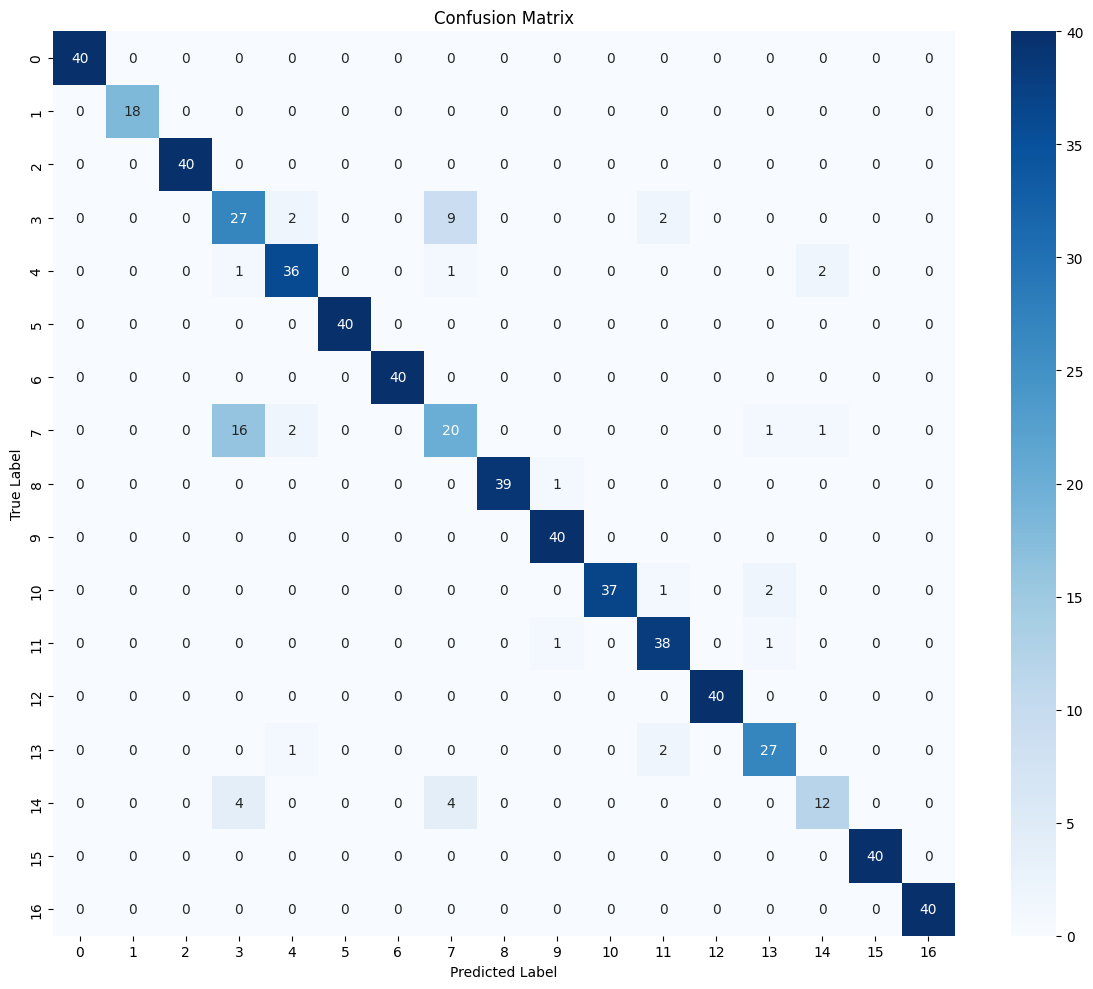

In [5]:
from script.analyze.analyze_gradcam import analyze_gradcam
from script.analyze.visualize_gradcam import visualize_gradcam
from src.utils.result import result_analysis, confusion_matrix_analysis

df, correct_dict, incorrect_dict = analyze_gradcam(model, dm)

result_analysis(df)
confusion_matrix_analysis(df)

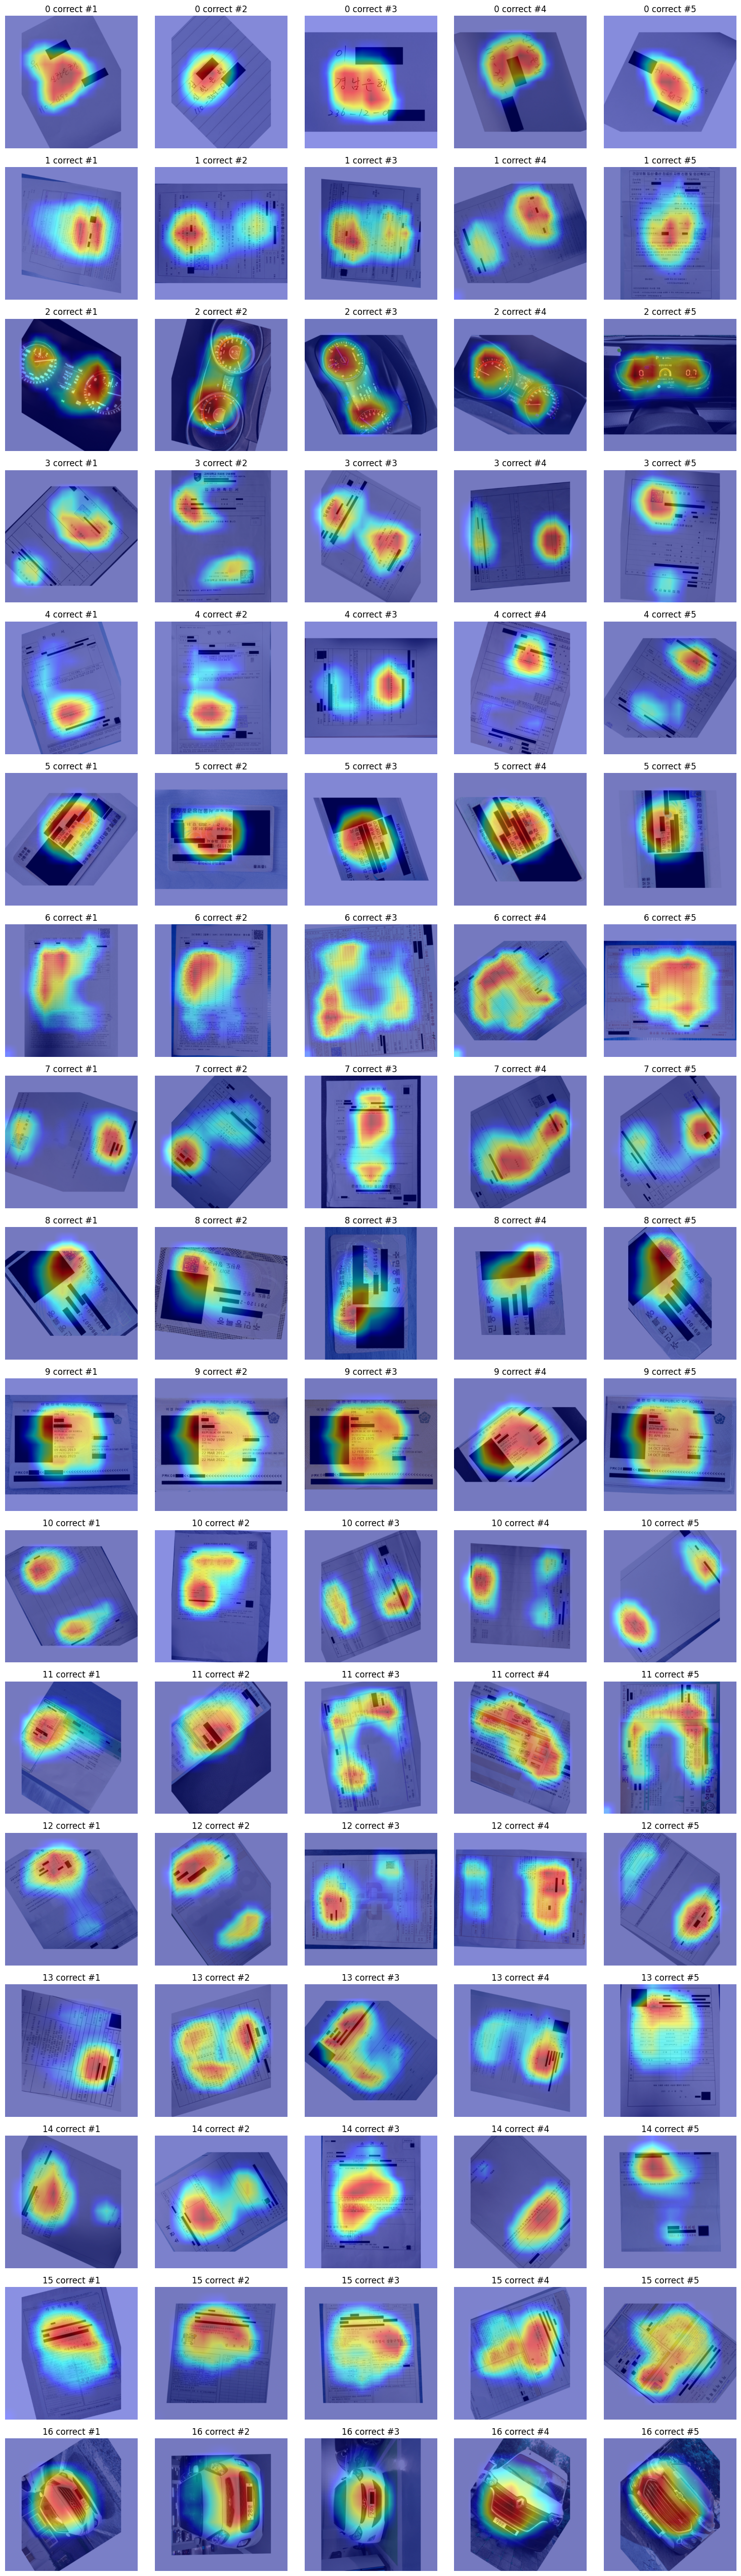

In [8]:
model = model.model
target_layer = model.conv_head
title = "correct"

visualize_gradcam(model, correct_dict, target_layer=target_layer, title=title)

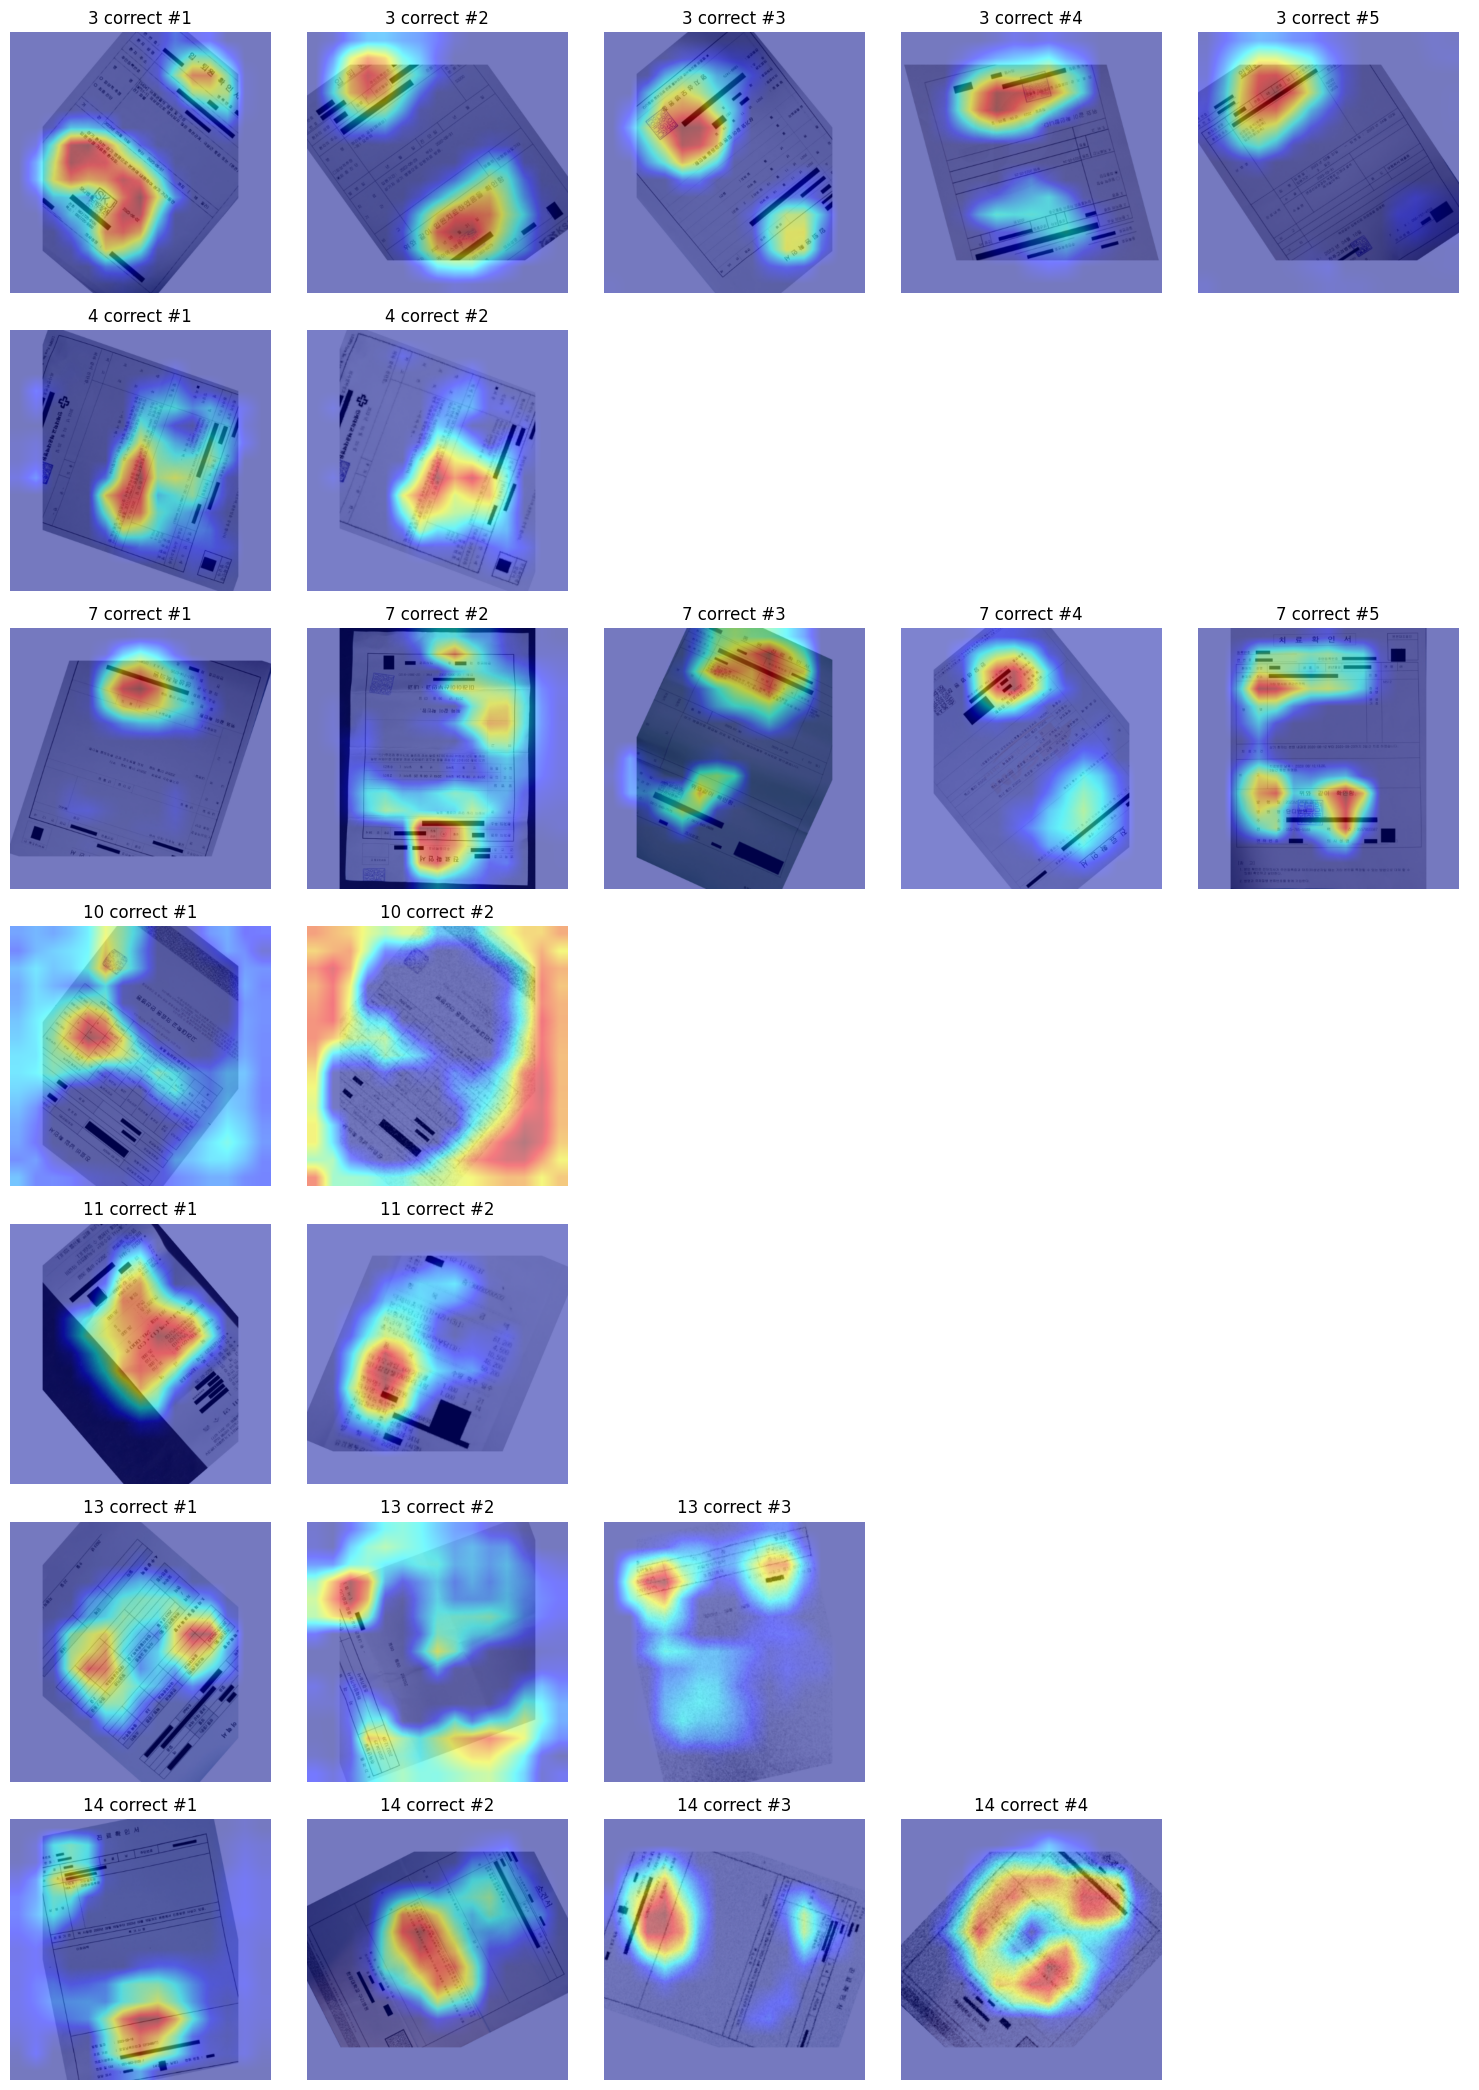

In [ ]:
title = "incorrect"
visualize_gradcam(model, incorrect_dict, target_layer=target_layer, title=title)